# Team 4 - US Accidents Severity Multiclass Classification

## 프로젝트 목적

본 노트북은 Kaggle의 **US Accidents (2016–2023)** 데이터를 활용하여 교통사고 심각도(`Severity`)를 예측하는 다중분류 모델을 구축한다.

예측 대상은 `Severity`이며, 클래스는 1, 2, 3, 4이다.

## 분석 방향

- 원본 데이터에서 사고 발생 시점에 활용 가능하다고 판단되는 변수만 선택한다.
- `End_Time`, `Distance(mi)`, `Duration_Min`처럼 사고 발생 이후 정보 또는 사고 영향 범위를 직접 반영할 가능성이 있는 변수는 제외한다.
- `Severity` 기준 층화 샘플링을 적용하여 클래스 분포를 유지한다.
- 클래스 불균형이 있으므로 Accuracy만 보지 않고 Balanced Accuracy, Macro F1, Weighted F1을 함께 확인한다.
- 모델은 Dummy Baseline, Logistic Regression, Logistic Regression Balanced, Random Forest, HistGradientBoosting, XGBoost를 비교한다.

## 중요 수정 사항

`HistGradientBoostingClassifier`는 sparse matrix를 입력으로 받을 수 없다.  
따라서 이 노트북에서는 전처리 파이프라인을 두 개로 나눈다.

- One-Hot Encoding 기반 sparse 전처리: Logistic Regression, Random Forest, XGBoost
- Ordinal Encoding 기반 dense 전처리: HistGradientBoosting

# 1. 라이브러리 불러오기

데이터 처리, 시각화, 전처리, 모델 학습, 평가에 필요한 라이브러리를 불러온다.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    ConfusionMatrixDisplay
)

RANDOM_STATE = 42
SAMPLE_SIZE = 100_000

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 120)

print('라이브러리 로드 완료')

라이브러리 로드 완료


# 2. 환경 설정 (VS Code / 로컬)

이 노트북은 VS Code의 로컬 Python 환경에서 실행한다.

`imbalanced-learn`(SMOTE에 사용)과 `xgboost`가 설치되어 있어야 한다.  
아래 셀은 현재 커널의 Python에 맞춰 필요한 패키지가 있는지 확인하고, 없으면 설치한다.

> 설치 후 import 오류(특히 NumPy 관련)가 나면, 커널을 재시작한 뒤 처음부터 다시 실행한다.

In [2]:
import sys
import subprocess

def ensure_package(import_name, pip_name=None):
    pip_name = pip_name or import_name
    try:
        __import__(import_name)
        print(f'{pip_name}: 설치되어 있음')
    except ImportError:
        print(f'{pip_name}: 설치 중...')
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pip_name], check=True)
        print(f'{pip_name}: 설치 완료 (오류 시 커널 재시작 후 다시 실행)')

# 핵심 패키지 확인
for imp, pip in [('numpy', 'numpy'), ('pandas', 'pandas'),
                 ('sklearn', 'scikit-learn'),
                 ('xgboost', 'xgboost'),
                 ('imblearn', 'imbalanced-learn')]:
    ensure_package(imp, pip)

numpy: 설치되어 있음
pandas: 설치되어 있음
scikit-learn: 설치되어 있음
xgboost: 설치되어 있음
imbalanced-learn: 설치되어 있음


# 3. CSV 파일 경로 설정

다운로드 폴더에 있는 `US_Accidents_March23.csv`를 읽는다.

경로는 사용자 이름과 실제 파일명에 맞게 수정한다. 파일명이 다르면 (예: `US_Accidents_March23.csv`가 아니라면) 아래 경로를 바꾼다.

In [3]:
import os

# 다운로드 폴더의 CSV 경로 (사용자 홈 기준으로 자동 구성)
file_path = r'C:\Users\harry\Downloads\archive\US_Accidents_March23.csv'

# 파일이 없으면 안내
if not os.path.exists(file_path):
    print('파일을 찾지 못했습니다:', file_path)
    print('Downloads 폴더의 CSV 파일 목록:')
    downloads = os.path.join(os.path.expanduser('~'), 'Downloads')
    if os.path.isdir(downloads):
        for f in os.listdir(downloads):
            if f.lower().endswith('.csv'):
                print('  -', f)
    print('위 목록을 참고하여 file_path를 직접 지정하세요.')
else:
    print('CSV 경로:', file_path)

CSV 경로: C:\Users\harry\Downloads\archive\US_Accidents_March23.csv


# 4. 사용할 변수 선택

데이터에는 많은 변수가 있지만, 본 프로젝트에서는 사고 발생 시점에 확인 가능하다고 판단되는 변수만 사용한다.

## 사용 변수

- 목표 변수: `Severity`
- 시간 변수: `Start_Time`
- 위치 변수: `Start_Lat`, `Start_Lng`, `State`, `County`, `City`, `Timezone`
- 기상 변수: 온도, 습도, 기압, 가시거리, 풍속, 강수량, 기상 상태 등
- 주야간 변수: `Sunrise_Sunset`, `Civil_Twilight`, `Nautical_Twilight`, `Astronomical_Twilight`
- 도로환경 변수: `Amenity`, `Crossing`, `Junction`, `Traffic_Signal` 등

## 제외 변수

- `End_Time`: 사고 종료 이후 확정되는 정보
- `Distance(mi)`: 사고 영향 범위를 직접 반영할 가능성이 있는 정보
- `Duration_Min`: `End_Time`으로부터 만들어지는 사고 지속시간 정보
- `End_Lat`, `End_Lng`: 사고 종료 위치 정보
- `Description`, `Street`, `Zipcode`, `ID`: 텍스트 또는 식별자 성격이 강한 변수

In [4]:
USE_COLS = [
    # target
    'Severity',

    # time
    'Start_Time',

    # location
    'Start_Lat',
    'Start_Lng',
    'State',
    'County',
    'City',
    'Timezone',

    # weather numeric
    'Temperature(F)',
    'Wind_Chill(F)',
    'Humidity(%)',
    'Pressure(in)',
    'Visibility(mi)',
    'Wind_Speed(mph)',
    'Precipitation(in)',

    # weather categorical
    'Wind_Direction',
    'Weather_Condition',

    # day/night
    'Sunrise_Sunset',
    'Civil_Twilight',
    'Nautical_Twilight',
    'Astronomical_Twilight',

    # road environment
    'Amenity',
    'Bump',
    'Crossing',
    'Give_Way',
    'Junction',
    'No_Exit',
    'Railway',
    'Roundabout',
    'Station',
    'Stop',
    'Traffic_Calming',
    'Traffic_Signal',
    'Turning_Loop'
]

print('선택한 원천 변수 수:', len(USE_COLS))

선택한 원천 변수 수: 34


# 5. 데이터 불러오기

`usecols` 옵션을 사용하여 필요한 열만 불러온다.  
이렇게 하면 메모리 사용량을 줄일 수 있다.

In [5]:
df = pd.read_csv(file_path, usecols=USE_COLS, low_memory=False)

print('원본 데이터 크기:', df.shape)
display(df.head())

원본 데이터 크기: (7728394, 34)


,Severity,Start_Time,Start_Lat,Start_Lng,City,County,State,Timezone,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,3,2016-02-08 05:46:00,39.865147,-84.058723,Dayton,Montgomery,OH,US/Eastern,36.9,NaN,91.0,29.68,10.0,Calm,NaN,0.02,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Night
1,2,2016-02-08 06:07:59,39.928059,-82.831184,Reynoldsburg,Franklin,OH,US/Eastern,37.9,NaN,100.0,29.65,10.0,Calm,NaN,0.00,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Day
2,2,2016-02-08 06:49:27,39.063148,-84.032608,Williamsburg,Clermont,OH,US/Eastern,36.0,33.3,100.0,29.67,10.0,SW,3.5,NaN,Overcast,False,False,False,False,False,False,False,False,False,False,False,True,False,Night,Night,Day,Day
3,3,2016-02-08 07:23:34,39.747753,-84.205582,Dayton,Montgomery,OH,US/Eastern,35.1,31.0,96.0,29.64,9.0,SW,4.6,NaN,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Day,Day,Day
4,2,2016-02-08 07:39:07,39.627781,-84.188354,Dayton,Montgomery,OH,US/Eastern,36.0,33.3,89.0,29.65,6.0,SW,3.5,NaN,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,True,False,Day,Day,Day,Day


# 6. Severity 분포 확인

`Severity`는 예측 대상이다.  
클래스 분포를 먼저 확인하여 클래스 불균형이 있는지 파악한다.

In [6]:
original_severity_count = df['Severity'].value_counts().sort_index()
original_severity_ratio = df['Severity'].value_counts(normalize=True).sort_index()

original_severity_table = pd.DataFrame({
    'count': original_severity_count,
    'ratio': original_severity_ratio
})

display(original_severity_table)

,count,ratio
Severity,,
1,67366,0.008717
2,6156981,0.796670
3,1299337,0.168125
4,204710,0.026488


# 7. Severity 기준 층화 샘플링

원본 데이터는 규모가 크기 때문에, 전체 데이터를 그대로 사용하면 실행 시간이 길어질 수 있다.  
따라서 `Severity` 비율을 유지하면서 표본을 추출한다.

`stratify=df['Severity']`를 적용하면 원본과 샘플의 클래스 비율이 최대한 비슷하게 유지된다.

In [7]:
if len(df) > SAMPLE_SIZE:
    sampled_df, _ = train_test_split(
        df,
        train_size=SAMPLE_SIZE,
        random_state=RANDOM_STATE,
        stratify=df['Severity']
    )
else:
    sampled_df = df.copy()

sampled_df = sampled_df.reset_index(drop=True)

print('샘플링 후 데이터 크기:', sampled_df.shape)

sample_severity_table = pd.DataFrame({
    'original_ratio': df['Severity'].value_counts(normalize=True).sort_index(),
    'sample_ratio': sampled_df['Severity'].value_counts(normalize=True).sort_index()
})

display(sample_severity_table)

샘플링 후 데이터 크기: (100000, 34)


,original_ratio,sample_ratio
Severity,,
1,0.008717,0.00872
2,0.796670,0.79667
3,0.168125,0.16812
4,0.026488,0.02649


# 8. 전처리 함수 정의

원본 데이터를 모델 학습에 적합한 형태로 바꾼다.

## 처리 내용

1. `Start_Time`에서 `Year`, `Month`, `DayOfWeek`, `Hour` 생성
2. `Weather_Condition`을 `Weather_Group`으로 단순화
3. `Precipitation(in)` 결측 여부를 `Precipitation_NA`로 저장
4. `City`, `County`는 결측치만 채운다 (상위 30개 범주 축소는 정보 누수 방지를 위해 train 분할 이후에 수행)
5. True/False 도로환경 변수는 0/1로 변환

`End_Time`, `Distance(mi)`, `Duration_Min`은 사용하지 않는다.

In [8]:
def simplify_weather(x):
    if pd.isna(x):
        return 'Unknown'

    x = str(x).lower()

    if 'clear' in x or 'fair' in x:
        return 'Clear'
    elif 'cloud' in x or 'overcast' in x:
        return 'Cloudy'
    elif 'rain' in x or 'drizzle' in x or 'shower' in x:
        return 'Rain'
    elif 'snow' in x or 'sleet' in x or 'ice' in x:
        return 'Snow'
    elif 'fog' in x or 'mist' in x or 'haze' in x:
        return 'Fog'
    else:
        return 'Other'


def preprocess_raw_data(raw_df):
    data = raw_df.copy()

    # Start_Time 처리
    data['Start_Time'] = pd.to_datetime(
        data['Start_Time'],
        errors='coerce',
        format='mixed'
    )

    data['Year'] = data['Start_Time'].dt.year
    data['Month'] = data['Start_Time'].dt.month
    data['DayOfWeek'] = data['Start_Time'].dt.dayofweek
    data['Hour'] = data['Start_Time'].dt.hour

    data = data.drop(columns=['Start_Time'])

    # Weather_Condition 단순화
    data['Weather_Group'] = data['Weather_Condition'].apply(simplify_weather)
    data = data.drop(columns=['Weather_Condition'])

    # 강수량 결측 여부
    data['Precipitation_NA'] = data['Precipitation(in)'].isna().astype(int)

    # 고유값이 많은 지역 변수는 결측만 채운다.
    # 상위 30개 범주 축소는 정보 누수를 막기 위해 train 분할 이후에 수행한다.
    for col in ['City', 'County']:
        if col in data.columns:
            data[col] = data[col].fillna('Unknown')

    # bool 변수를 0/1로 변환
    bool_cols = data.select_dtypes(include=['bool']).columns.tolist()
    for col in bool_cols:
        data[col] = data[col].astype(int)

    return data


data = preprocess_raw_data(sampled_df)

print('전처리 후 데이터 크기:', data.shape)
display(data.head())

전처리 후 데이터 크기: (100000, 38)


,Severity,Start_Lat,Start_Lng,City,County,State,Timezone,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight,Year,Month,DayOfWeek,Hour,Weather_Group,Precipitation_NA
0,2,29.681866,-95.249031,Houston,Harris,TX,US/Central,78.1,NaN,66.0,29.97,10.0,SSE,19.6,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,Day,Day,Day,Day,2018,2,0,12,Cloudy,1
1,3,38.963650,-77.183487,Mc Lean,Fairfax County,VA,US/Eastern,69.0,69.0,75.0,30.34,10.0,E,14.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,Day,Day,Day,Day,2019,9,4,9,Cloudy,0
2,2,45.530380,-122.637530,Portland,Multnomah,OR,US/Pacific,51.0,51.0,54.0,30.08,10.0,SSW,10.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,Day,Day,Day,Day,2020,3,3,16,Cloudy,0
3,2,47.821847,-122.277882,Lynnwood,Snohomish,WA,US/Pacific,59.0,59.0,78.0,29.17,2.0,S,9.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,Day,Day,Day,Day,2021,9,6,14,Rain,0
4,1,33.538550,-112.116940,Phoenix,Maricopa,AZ,US/Mountain,86.0,86.0,26.0,28.19,10.0,VAR,6.0,0.0,0,0,0,0,0,0,0,0,0,0,0,1,0,Day,Day,Day,Day,2020,6,5,15,Clear,0


# 9. 결측치 비율 확인

결측치는 이후 모델 Pipeline에서 처리한다.  
다만 보고서 작성과 데이터 이해를 위해 결측치 비율을 확인한다.

Precipitation(in)        0.28598
Wind_Chill(F)            0.25881
Wind_Speed(mph)          0.07424
Visibility(mi)           0.02320
Humidity(%)              0.02305
Wind_Direction           0.02286
Temperature(F)           0.02173
Pressure(in)             0.01876
Nautical_Twilight        0.00323
Astronomical_Twilight    0.00323
Civil_Twilight           0.00323
Sunrise_Sunset           0.00323
Timezone                 0.00092
Severity                 0.00000
State                    0.00000
County                   0.00000
City                     0.00000
Start_Lng                0.00000
Start_Lat                0.00000
Amenity                  0.00000
dtype: float64

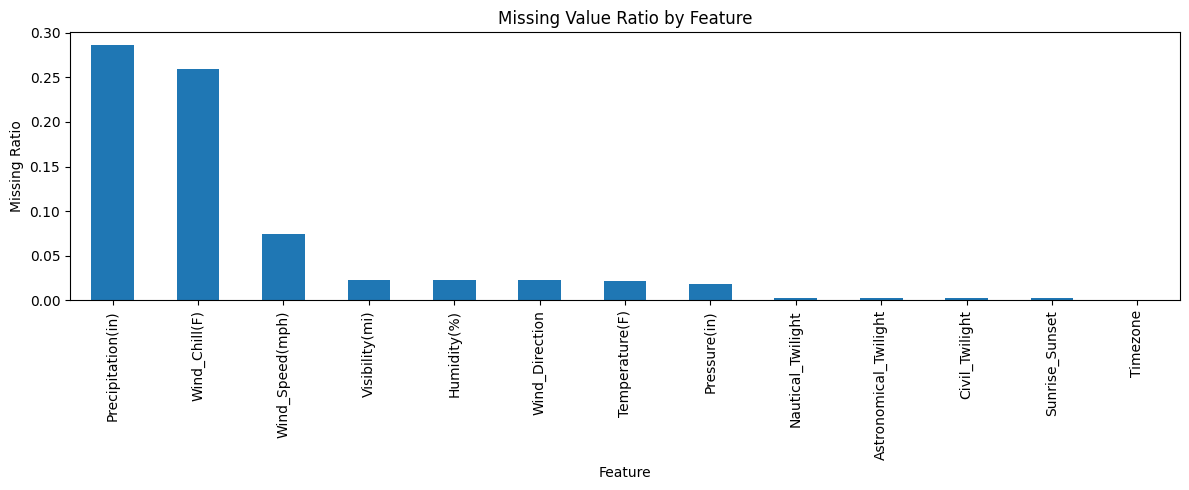

In [9]:
missing_ratio = data.isnull().mean().sort_values(ascending=False)

display(missing_ratio.head(20))

plt.figure(figsize=(12, 5))
missing_ratio[missing_ratio > 0].plot(kind='bar')
plt.title('Missing Value Ratio by Feature')
plt.ylabel('Missing Ratio')
plt.xlabel('Feature')
plt.tight_layout()
plt.show()

# 10. EDA 1 - Severity 클래스 분포

클래스 불균형 여부를 시각적으로 확인한다.

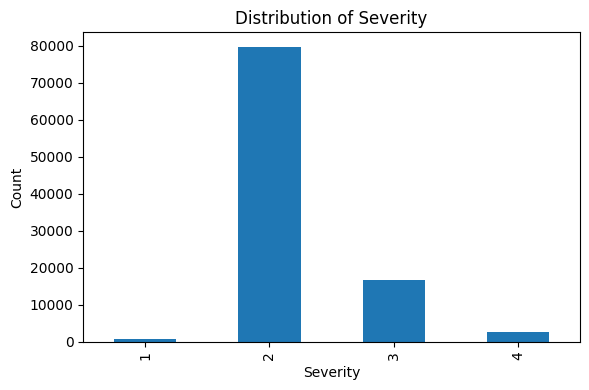

In [10]:
plt.figure(figsize=(6, 4))
data['Severity'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution of Severity')
plt.xlabel('Severity')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# 11. EDA 2 - 원본과 샘플의 Severity 비율 비교

층화 샘플링이 원본 클래스 비율을 잘 유지했는지 확인한다.

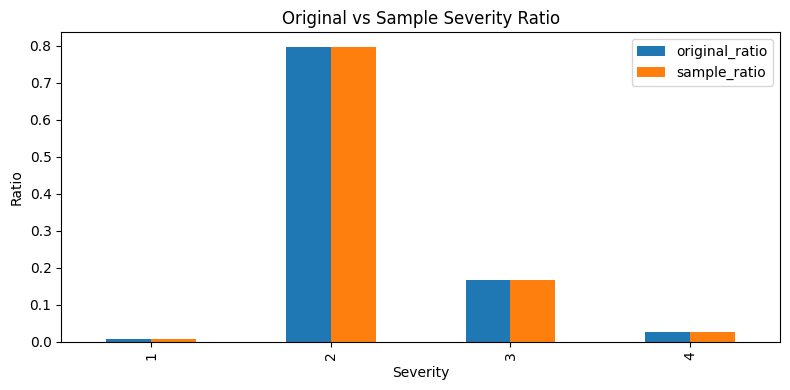

In [11]:
sample_severity_table.plot(kind='bar', figsize=(8, 4))
plt.title('Original vs Sample Severity Ratio')
plt.xlabel('Severity')
plt.ylabel('Ratio')
plt.tight_layout()
plt.show()

# 12. EDA 3 - 시간대별 사고 발생 수

사고가 특정 시간대에 집중되는지 확인한다.

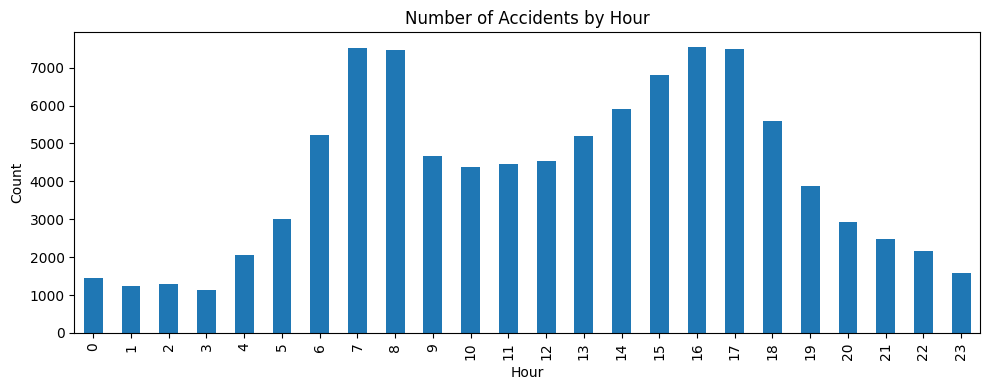

In [12]:
plt.figure(figsize=(10, 4))
data.groupby('Hour')['Severity'].count().plot(kind='bar')
plt.title('Number of Accidents by Hour')
plt.xlabel('Hour')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# 13. EDA 4 - 월별 사고 발생 수

월별 사고 발생 패턴을 확인한다.

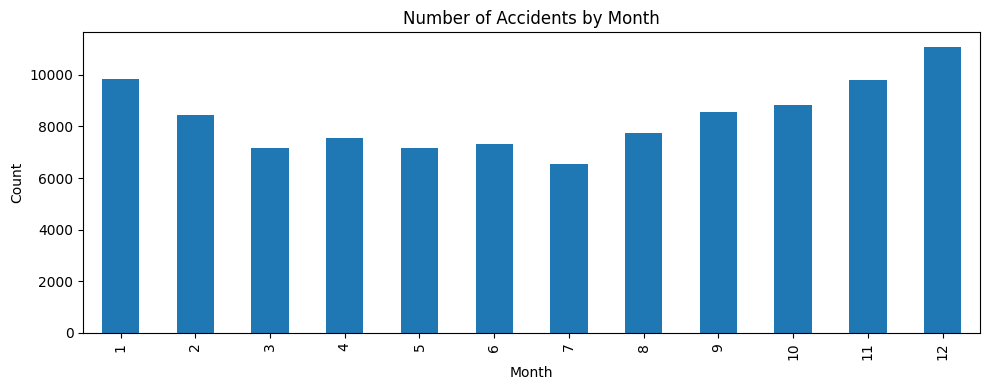

In [13]:
plt.figure(figsize=(10, 4))
data.groupby('Month')['Severity'].count().plot(kind='bar')
plt.title('Number of Accidents by Month')
plt.xlabel('Month')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# 14. EDA 5 - Weather_Group별 Severity 분포

기상 상태 그룹에 따라 Severity 분포가 달라지는지 확인한다.

Severity,1,2,3,4
Weather_Group,,,,
Clear,0.010814,0.819317,0.144425,0.025444
Cloudy,0.008018,0.774602,0.191578,0.025801
Fog,0.002359,0.839953,0.137633,0.020055
Other,0.010647,0.826372,0.135135,0.027846
Rain,0.005901,0.763817,0.202073,0.028210
Snow,0.000484,0.799129,0.154889,0.045499
Unknown,0.002641,0.783891,0.170335,0.043134


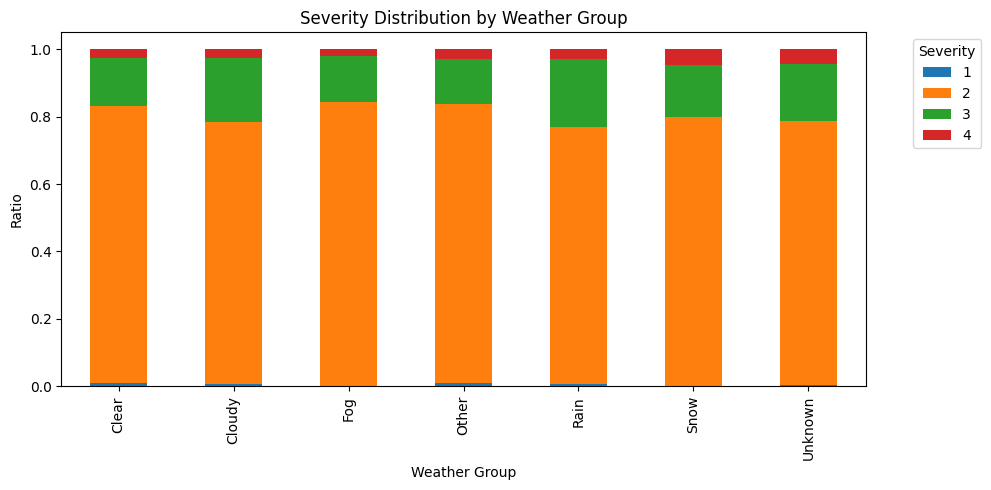

In [14]:
weather_severity = pd.crosstab(
    data['Weather_Group'],
    data['Severity'],
    normalize='index'
)

display(weather_severity)

weather_severity.plot(kind='bar', stacked=True, figsize=(10, 5))
plt.title('Severity Distribution by Weather Group')
plt.xlabel('Weather Group')
plt.ylabel('Ratio')
plt.legend(title='Severity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 15. EDA 6 - Traffic_Signal별 Severity 분포

신호등 여부에 따라 Severity 분포가 달라지는지 확인한다.

Severity,1,2,3,4
Traffic_Signal,,,,
0,0.006347,0.781893,0.183909,0.027851
1,0.022422,0.881994,0.076954,0.018629


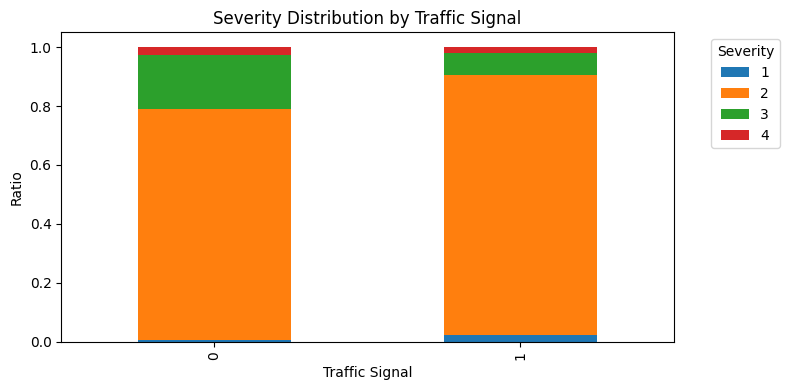

In [15]:
signal_severity = pd.crosstab(
    data['Traffic_Signal'],
    data['Severity'],
    normalize='index'
)

display(signal_severity)

signal_severity.plot(kind='bar', stacked=True, figsize=(8, 4))
plt.title('Severity Distribution by Traffic Signal')
plt.xlabel('Traffic Signal')
plt.ylabel('Ratio')
plt.legend(title='Severity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 16. EDA 7 - Junction별 Severity 분포

교차부 여부에 따라 Severity 분포가 달라지는지 확인한다.

Severity,1,2,3,4
Junction,,,,
0,0.009026,0.801663,0.163399,0.025912
1,0.004878,0.734011,0.227371,0.033740


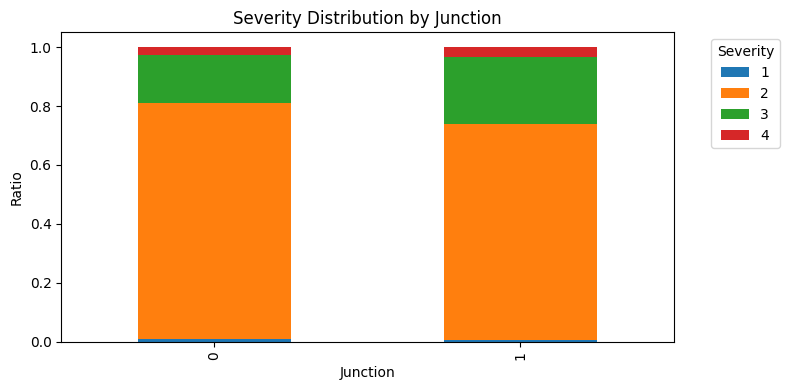

In [16]:
junction_severity = pd.crosstab(
    data['Junction'],
    data['Severity'],
    normalize='index'
)

display(junction_severity)

junction_severity.plot(kind='bar', stacked=True, figsize=(8, 4))
plt.title('Severity Distribution by Junction')
plt.xlabel('Junction')
plt.ylabel('Ratio')
plt.legend(title='Severity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 17. EDA 8 - Severity별 평균 가시거리

기상 조건과 관련된 가시거리 변수가 Severity별로 차이가 있는지 확인한다.

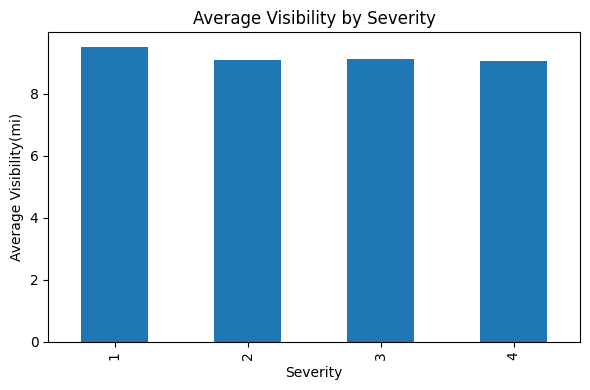

In [17]:
plt.figure(figsize=(6, 4))
data.groupby('Severity')['Visibility(mi)'].mean().plot(kind='bar')
plt.title('Average Visibility by Severity')
plt.xlabel('Severity')
plt.ylabel('Average Visibility(mi)')
plt.tight_layout()
plt.show()

# 18. EDA 9 - 사고 건수 상위 10개 주

지역별 사고 데이터 분포를 확인한다. 지역 변수는 예측에 도움이 될 수 있지만, 특정 지역의 데이터 편향을 반영할 수도 있다.

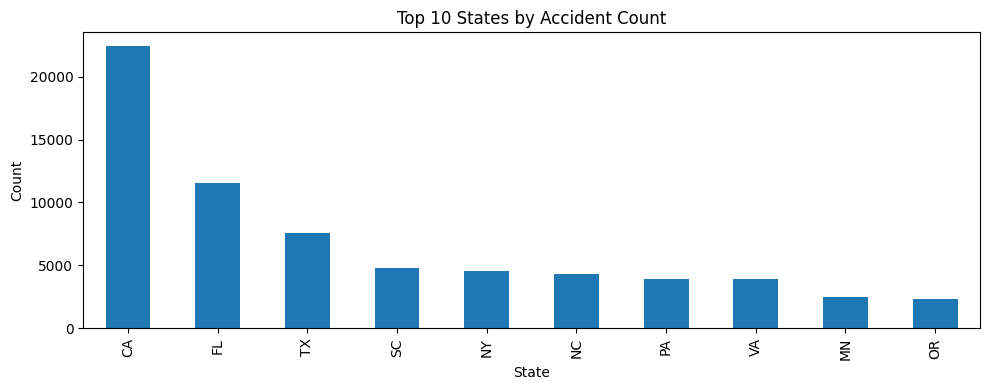

In [18]:
plt.figure(figsize=(10, 4))
data['State'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 States by Accident Count')
plt.xlabel('State')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# 19. EDA 10 - 도로환경 변수 True 비율

도로환경 변수들이 데이터에서 얼마나 자주 나타나는지 확인한다.

Traffic_Signal     0.14762
Crossing           0.11293
Junction           0.07380
Stop               0.02792
Station            0.02593
Amenity            0.01261
Railway            0.00855
Give_Way           0.00502
No_Exit            0.00270
Traffic_Calming    0.00090
Bump               0.00035
Roundabout         0.00002
Turning_Loop       0.00000
dtype: float64

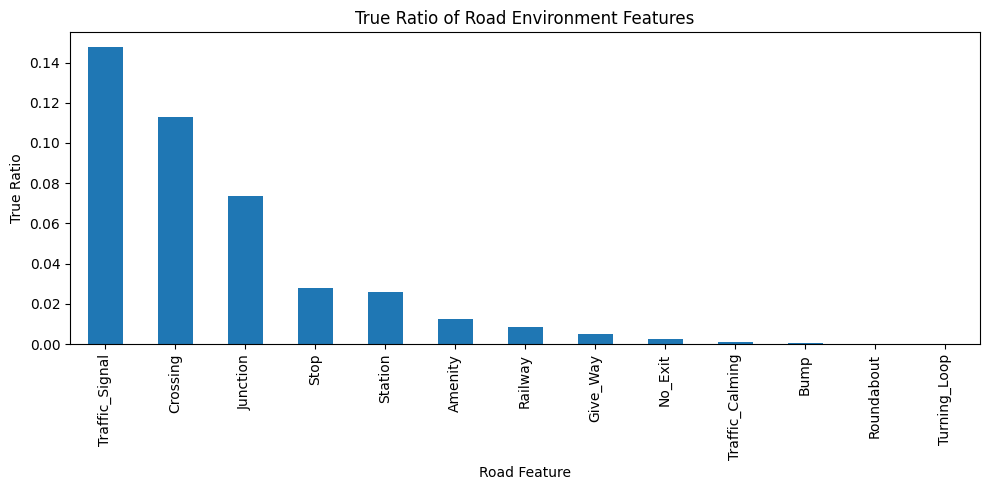

In [19]:
road_cols = [
    'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit',
    'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming',
    'Traffic_Signal', 'Turning_Loop'
]

road_true_ratio = data[road_cols].mean().sort_values(ascending=False)

display(road_true_ratio)

plt.figure(figsize=(10, 5))
road_true_ratio.plot(kind='bar')
plt.title('True Ratio of Road Environment Features')
plt.xlabel('Road Feature')
plt.ylabel('True Ratio')
plt.tight_layout()
plt.show()

# 20. X, y 분리

`Severity`는 예측 대상이므로 `y`로 분리하고, 나머지는 입력 변수 `X`로 사용한다.

In [20]:
X = data.drop(columns=['Severity'])
y = data['Severity']

print('X shape:', X.shape)
print('y shape:', y.shape)
display(y.value_counts(normalize=True).sort_index())

X shape: (100000, 37)
y shape: (100000,)


Severity
1    0.00872
2    0.79667
3    0.16812
4    0.02649
Name: proportion, dtype: float64

# 21. Train / Validation / Test 분할

모델 비교와 최종 평가를 분리하기 위해 데이터를 세 부분으로 나눈다.

- Train: 모델 학습
- Validation: 모델 비교 및 선택
- Test: 최종 모델 평가

모든 분할에서 `stratify`를 적용하여 클래스 비율을 유지한다.

In [21]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=RANDOM_STATE,
    stratify=y
)

valid_ratio = 0.15 / 0.85

X_train, X_valid, y_train, y_valid = train_test_split(
    X_temp,
    y_temp,
    test_size=valid_ratio,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print('Train:', X_train.shape, y_train.shape)
print('Validation:', X_valid.shape, y_valid.shape)
print('Test:', X_test.shape, y_test.shape)

split_ratio_table = pd.DataFrame({
    'train_ratio': y_train.value_counts(normalize=True).sort_index(),
    'valid_ratio': y_valid.value_counts(normalize=True).sort_index(),
    'test_ratio': y_test.value_counts(normalize=True).sort_index()
})

display(split_ratio_table)

Train: (69999, 37) (69999,)
Validation: (15001, 37) (15001,)
Test: (15000, 37) (15000,)


,train_ratio,valid_ratio,test_ratio
Severity,,,
1,0.008714,0.008733,0.008733
2,0.796669,0.796680,0.796667
3,0.168117,0.168122,0.168133
4,0.026500,0.026465,0.026467


# 21-1. 지역 변수 상위 범주 축소 (train 기준)

`City`, `County`는 고유값이 매우 많다. 상위 30개 범주만 남기고 나머지는 `Other`로 통합한다.

중요한 점은 **상위 30개 목록을 train 데이터에서만 학습**한다는 것이다.  
전체 데이터에서 빈도를 계산하면 valid/test 정보가 train 전처리에 새어드는 미세한 정보 누수가 발생하므로, 이를 피하기 위해 분할 이후에 수행한다.

In [22]:
def fit_top_categories(series, top_n=30):
    """train 데이터에서 상위 top_n 범주 목록을 학습한다."""
    return series.value_counts().head(top_n).index

def apply_top_categories(series, top_values):
    """학습된 상위 범주 목록을 적용한다. 목록 밖 값은 Other로 통합."""
    return series.where(series.isin(top_values), other='Other')

# train에서만 상위 범주를 학습한 뒤 valid/test에 동일하게 적용
top_category_map = {}
for col in ['City', 'County']:
    if col in X_train.columns:
        top_values = fit_top_categories(X_train[col], top_n=30)
        top_category_map[col] = top_values

        X_train[col] = apply_top_categories(X_train[col], top_values)
        X_valid[col] = apply_top_categories(X_valid[col], top_values)
        X_test[col]  = apply_top_categories(X_test[col],  top_values)

for col, vals in top_category_map.items():
    print(f'{col}: train 기준 상위 {len(vals)}개 범주 유지, 나머지는 Other')

print()
print('축소 후 City 고유값 수 (train):', X_train['City'].nunique())
print('축소 후 County 고유값 수 (train):', X_train['County'].nunique())

City: train 기준 상위 30개 범주 유지, 나머지는 Other
County: train 기준 상위 30개 범주 유지, 나머지는 Other

축소 후 City 고유값 수 (train): 31
축소 후 County 고유값 수 (train): 31


# 22. 수치형 / 범주형 변수 구분

수치형 변수와 범주형 변수는 서로 다른 전처리가 필요하다.

이후 전처리 파이프라인에서 다음을 적용한다.

- 수치형: 결측치 중앙값 대체, 표준화 또는 중앙값 대체
- 범주형: 결측치 최빈값 대체, One-Hot Encoding 또는 Ordinal Encoding

In [23]:
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

print('수치형 변수 수:', len(numeric_features))
print(numeric_features)

print('범주형 변수 수:', len(categorical_features))
print(categorical_features)

수치형 변수 수: 23
['Start_Lat', 'Start_Lng', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'Precipitation_NA']
범주형 변수 수: 10
['City', 'County', 'State', 'Timezone', 'Wind_Direction', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight', 'Weather_Group']


# 23. 전처리 파이프라인 구성

이전 오류의 원인은 `HistGradientBoostingClassifier`가 sparse matrix를 받을 수 없는데, One-Hot Encoding 결과가 sparse matrix였기 때문이다.

따라서 전처리 파이프라인을 두 개로 나눈다.

## sparse_preprocessor

- One-Hot Encoding 사용
- Logistic Regression, Random Forest, XGBoost에 사용

## dense_preprocessor

- Ordinal Encoding 사용
- HistGradientBoosting에 사용
- sparse matrix가 나오지 않으므로 오류가 발생하지 않음

In [24]:
# One-Hot Encoding 기반 전처리: sparse 입력을 받을 수 있는 모델에 사용
numeric_transformer_sparse = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer_sparse = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

sparse_preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_sparse, numeric_features),
        ('cat', categorical_transformer_sparse, categorical_features)
    ],
    sparse_threshold=1.0
)

# Ordinal Encoding 기반 전처리: dense 입력이 필요한 HistGradientBoosting에 사용
numeric_transformer_dense = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer_dense = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

dense_preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_dense, numeric_features),
        ('cat', categorical_transformer_dense, categorical_features)
    ],
    sparse_threshold=0.0
)

print('전처리 파이프라인 2개 구성 완료')

전처리 파이프라인 2개 구성 완료


# 24. 평가 함수 정의

클래스 불균형을 고려하여 다양한 지표를 함께 계산한다.

- Accuracy: 전체 정확도
- Balanced Accuracy: 클래스별 Recall 평균
- Macro F1: 각 클래스를 동일한 비중으로 계산한 F1
- Weighted F1: 클래스 비율을 반영한 F1
- Macro Precision / Macro Recall: 클래스별 평균 정밀도와 재현율

모델 선택은 주로 `Macro_F1`을 기준으로 한다.

In [25]:
def evaluate_predictions(model_name, y_true, y_pred):
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Balanced_Accuracy': balanced_accuracy_score(y_true, y_pred),
        'Macro_F1': f1_score(y_true, y_pred, average='macro'),
        'Weighted_F1': f1_score(y_true, y_pred, average='weighted'),
        'Macro_Precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Macro_Recall': recall_score(y_true, y_pred, average='macro', zero_division=0)
    }


def evaluate_model(model_name, model, X_data, y_true):
    y_pred = model.predict(X_data)
    return evaluate_predictions(model_name, y_true, y_pred)


metric_cols = [
    'Accuracy',
    'Balanced_Accuracy',
    'Macro_F1',
    'Weighted_F1',
    'Macro_Precision',
    'Macro_Recall'
]

print('평가 함수 정의 완료')

평가 함수 정의 완료


# 25. 기본 비교 모델 정의

모델별로 적절한 전처리 파이프라인을 연결한다.

- Dummy Baseline: sparse_preprocessor
- Logistic Regression: sparse_preprocessor
- Logistic Regression Balanced: sparse_preprocessor
- Random Forest: sparse_preprocessor
- HistGradientBoosting: dense_preprocessor

`HistGradientBoosting`은 dense 전처리를 사용하므로 sparse matrix 오류가 발생하지 않는다.

In [26]:
models = {
    'Dummy Baseline': Pipeline(steps=[
        ('preprocess', sparse_preprocessor),
        ('model', DummyClassifier(strategy='most_frequent'))
    ]),

    'Logistic Regression': Pipeline(steps=[
        ('preprocess', sparse_preprocessor),
        ('model', LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE
        ))
    ]),

    'Logistic Regression Balanced': Pipeline(steps=[
        ('preprocess', sparse_preprocessor),
        ('model', LogisticRegression(
            max_iter=1000,
            class_weight='balanced',
            random_state=RANDOM_STATE
        ))
    ]),

    'Random Forest': Pipeline(steps=[
        ('preprocess', sparse_preprocessor),
        ('model', RandomForestClassifier(
            n_estimators=200,
            max_depth=None,
            min_samples_leaf=3,
            class_weight='balanced_subsample',
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),

    'HistGradientBoosting': Pipeline(steps=[
        ('preprocess', dense_preprocessor),
        ('model', HistGradientBoostingClassifier(
            max_iter=200,
            learning_rate=0.08,
            max_leaf_nodes=31,
            random_state=RANDOM_STATE
        ))
    ])
}

print('기본 비교 모델 수:', len(models))

기본 비교 모델 수: 5


# 26. 기본 모델 학습 및 Validation 평가

모든 기본 모델을 동일한 Train 데이터로 학습하고, 동일한 Validation 데이터로 평가한다.

이 단계에서 Test 데이터는 사용하지 않는다.

In [27]:
validation_results = []
fitted_models = {}

for name, model in models.items():
    print(f'학습 중: {name}')
    model.fit(X_train, y_train)
    fitted_models[name] = model

    result = evaluate_model(name, model, X_valid, y_valid)
    validation_results.append(result)

validation_result_df = pd.DataFrame(validation_results).sort_values(
    by='Macro_F1',
    ascending=False
)

display(validation_result_df)

학습 중: Dummy Baseline
학습 중: Logistic Regression
학습 중: Logistic Regression Balanced
학습 중: Random Forest
학습 중: HistGradientBoosting


,Model,Accuracy,Balanced_Accuracy,Macro_F1,Weighted_F1,Macro_Precision,Macro_Recall
3,Random Forest,0.762749,0.386328,0.384953,0.765768,0.388781,0.386328
4,HistGradientBoosting,0.811213,0.304214,0.318014,0.763609,0.546433,0.304214
2,Logistic Regression Balanced,0.413039,0.533000,0.283008,0.504828,0.339162,0.533000
1,Logistic Regression,0.801613,0.276575,0.273395,0.742091,0.338006,0.276575
0,Dummy Baseline,0.796680,0.250000,0.221709,0.706525,0.199170,0.250000


# 27. XGBoost 추가 실험

XGBoost는 추가 비교 모델로 사용한다.

Colab에서 GPU가 활성화되어 있으면 `device='cuda'` 옵션을 먼저 시도한다.  
GPU 환경 문제로 실패하면 CPU 설정으로 자동 재시도한다.

XGBoost는 클래스 라벨이 0부터 시작하는 것을 선호하므로 `LabelEncoder`를 적용한다.

또한 XGBoost에는 `class_weight` 인자가 없으므로, 다른 모델과 공정하게 비교하기 위해 `compute_sample_weight`로 클래스 균형 가중치를 만들어 `sample_weight`로 적용한다.

In [28]:
import sys, subprocess
try:
    import xgboost
    print('xgboost version:', xgboost.__version__)
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'xgboost'], check=True)
    import xgboost
    print('xgboost version:', xgboost.__version__)

xgboost version: 3.2.0


In [29]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight

le = LabelEncoder()

y_train_xgb = le.fit_transform(y_train)
y_valid_xgb = le.transform(y_valid)
y_test_xgb = le.transform(y_test)

# 다른 모델(RF, LR Balanced)은 class_weight='balanced'로 불균형을 보정한다.
# XGBoost에는 class_weight 인자가 없으므로, 동일한 효과를 위해
# 클래스 가중치를 sample_weight로 만들어 학습에 적용한다.
# 이렇게 해야 모델 간 비교가 공정해진다.
xgb_sample_weight = compute_sample_weight(class_weight='balanced', y=y_train_xgb)

xgb_model = Pipeline(steps=[
    ('preprocess', sparse_preprocessor),
    ('model', XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.08,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric='mlogloss',
        random_state=RANDOM_STATE,
        tree_method='hist',
        device='cuda',
        n_jobs=-1
    ))
])

try:
    print('XGBoost GPU 학습 시도')
    xgb_model.fit(X_train, y_train_xgb, model__sample_weight=xgb_sample_weight)
except Exception as e:
    print('GPU 학습 실패. CPU 설정으로 재시도합니다.')
    print('오류 내용:', e)

    xgb_model = Pipeline(steps=[
        ('preprocess', sparse_preprocessor),
        ('model', XGBClassifier(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.08,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric='mlogloss',
            random_state=RANDOM_STATE,
            tree_method='hist',
            n_jobs=-1
        ))
    ])

    xgb_model.fit(X_train, y_train_xgb, model__sample_weight=xgb_sample_weight)

xgb_valid_pred_encoded = xgb_model.predict(X_valid)
xgb_valid_pred = le.inverse_transform(xgb_valid_pred_encoded)

xgb_valid_result = evaluate_predictions('XGBoost Balanced', y_valid, xgb_valid_pred)

fitted_models['XGBoost Balanced'] = xgb_model

validation_result_df = pd.concat(
    [validation_result_df, pd.DataFrame([xgb_valid_result])],
    ignore_index=True
).sort_values(by='Macro_F1', ascending=False)

display(validation_result_df)

XGBoost GPU 학습 시도


,Model,Accuracy,Balanced_Accuracy,Macro_F1,Weighted_F1,Macro_Precision,Macro_Recall
0,Random Forest,0.762749,0.386328,0.384953,0.765768,0.388781,0.386328
5,XGBoost Balanced,0.525365,0.543391,0.332812,0.604680,0.353554,0.543391
1,HistGradientBoosting,0.811213,0.304214,0.318014,0.763609,0.546433,0.304214
2,Logistic Regression Balanced,0.413039,0.533000,0.283008,0.504828,0.339162,0.533000
3,Logistic Regression,0.801613,0.276575,0.273395,0.742091,0.338006,0.276575
4,Dummy Baseline,0.796680,0.250000,0.221709,0.706525,0.199170,0.250000


# 28. Validation 성능 비교 시각화

모델별 성능을 그래프로 비교한다.

Accuracy가 높더라도 Macro F1이 낮을 수 있으므로, 여러 지표를 함께 확인한다.

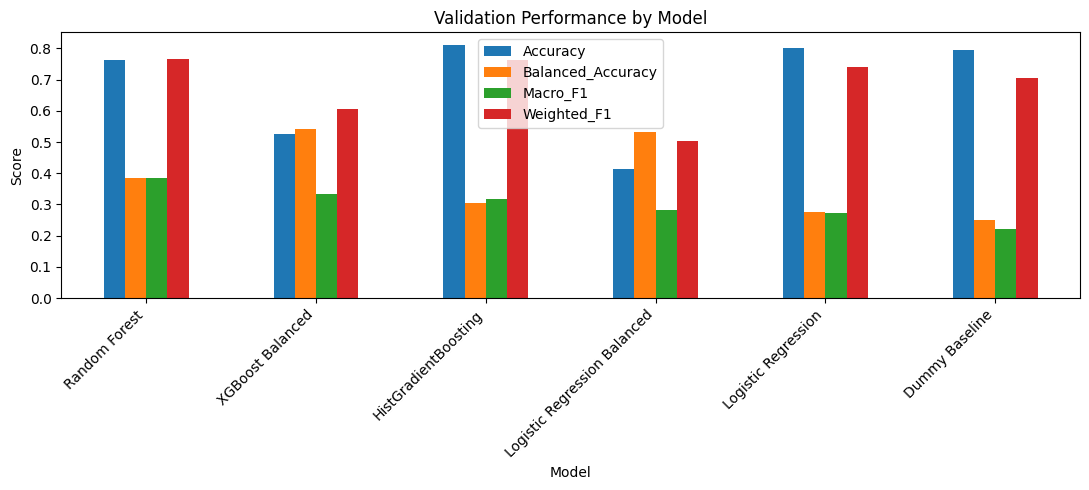

In [30]:
plot_df = validation_result_df.set_index('Model')[['Accuracy', 'Balanced_Accuracy', 'Macro_F1', 'Weighted_F1']]

plot_df.plot(kind='bar', figsize=(11, 5))
plt.title('Validation Performance by Model')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 29. 최종 모델 선택

Validation 데이터에서 `Macro_F1`이 가장 높은 모델을 최종 모델로 선택한다.

클래스 불균형이 있으므로 Accuracy가 아니라 Macro F1을 중심으로 모델을 선택한다.

In [31]:
best_model_name = validation_result_df.iloc[0]['Model']
best_model = fitted_models[best_model_name]

print('최종 선택 모델:', best_model_name)
display(validation_result_df.head())

최종 선택 모델: Random Forest


,Model,Accuracy,Balanced_Accuracy,Macro_F1,Weighted_F1,Macro_Precision,Macro_Recall
0,Random Forest,0.762749,0.386328,0.384953,0.765768,0.388781,0.386328
5,XGBoost Balanced,0.525365,0.543391,0.332812,0.604680,0.353554,0.543391
1,HistGradientBoosting,0.811213,0.304214,0.318014,0.763609,0.546433,0.304214
2,Logistic Regression Balanced,0.413039,0.533000,0.283008,0.504828,0.339162,0.533000
3,Logistic Regression,0.801613,0.276575,0.273395,0.742091,0.338006,0.276575


# 30. Test 데이터 최종 평가

최종 선택 모델에 대해서만 Test 데이터를 사용해 최종 성능을 평가한다.

In [32]:
if best_model_name == 'XGBoost Balanced':
    test_pred_encoded = best_model.predict(X_test)
    test_pred = le.inverse_transform(test_pred_encoded)
else:
    test_pred = best_model.predict(X_test)

test_result = evaluate_predictions(best_model_name, y_test, test_pred)
test_result_df = pd.DataFrame([test_result])

display(test_result_df)
print(classification_report(y_test, test_pred, zero_division=0))

,Model,Accuracy,Balanced_Accuracy,Macro_F1,Weighted_F1,Macro_Precision,Macro_Recall
0,Random Forest,0.7576,0.406675,0.40525,0.763043,0.409807,0.406675


              precision    recall  f1-score   support

           1       0.16      0.11      0.13       131
           2       0.87      0.83      0.85     11950
           3       0.43      0.52      0.47      2522
           4       0.18      0.16      0.17       397

    accuracy                           0.76     15000
   macro avg       0.41      0.41      0.41     15000
weighted avg       0.77      0.76      0.76     15000



# 31. Confusion Matrix

Confusion Matrix를 통해 어떤 클래스가 잘 맞고 어떤 클래스가 자주 오분류되는지 확인한다.

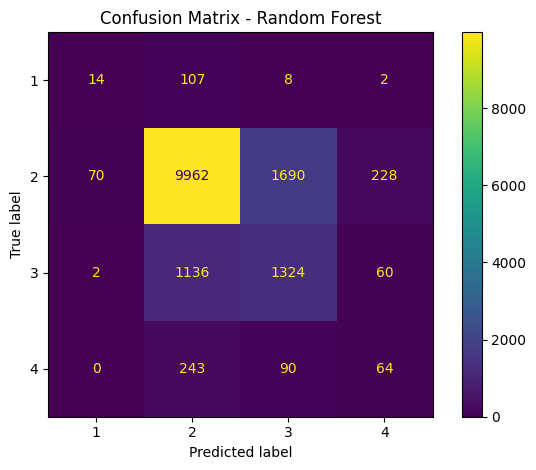

In [33]:
ConfusionMatrixDisplay.from_predictions(y_test, test_pred)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.tight_layout()
plt.show()

# 32. Random Forest Feature Importance

Random Forest의 Feature Importance를 확인한다.

이 결과는 어떤 변수가 예측에 많이 사용되었는지 보여주지만, 인과관계를 의미하지는 않는다.

,feature,importance
1,num__Start_Lng,0.089222
0,num__Start_Lat,0.089039
3,num__Wind_Chill(F),0.082989
5,num__Pressure(in),0.075395
2,num__Temperature(F),0.067836
4,num__Humidity(%),0.062499
7,num__Wind_Speed(mph),0.048287
22,num__Precipitation_NA,0.034860
20,num__Traffic_Signal,0.029627
76,cat__County_Other,0.017562


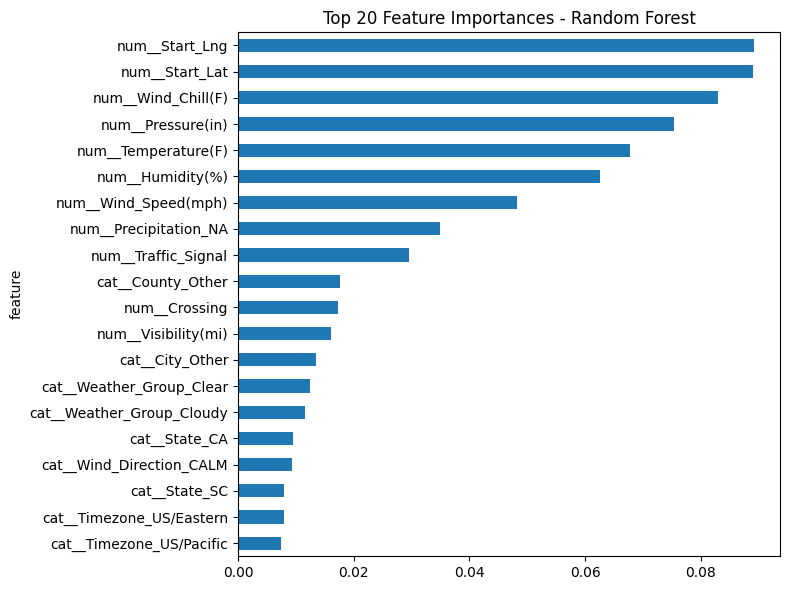

In [34]:
rf_model = fitted_models.get('Random Forest')

if rf_model is not None:
    rf_clf = rf_model.named_steps['model']
    feature_names = rf_model.named_steps['preprocess'].get_feature_names_out()

    rf_importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': rf_clf.feature_importances_
    }).sort_values(by='importance', ascending=False)

    display(rf_importance_df.head(20))

    rf_importance_df.head(20).plot(
        x='feature',
        y='importance',
        kind='barh',
        legend=False,
        figsize=(8, 6)
    )
    plt.title('Top 20 Feature Importances - Random Forest')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print('Random Forest 모델이 없습니다.')

# 33. Random Forest 하이퍼파라미터 변화 분석

Random Forest의 `max_depth`를 바꾸면서 Validation 성능 변화를 확인한다.

- `max_depth`가 너무 작으면 언더피팅 가능성
- `max_depth`가 너무 크면 과적합 가능성

이 결과는 보고서의 하이퍼파라미터 변경 효과 분석에 사용할 수 있다.

In [35]:
rf_depth_results = []

for depth in [5, 10, 15, 20, None]:
    depth_label = 'None' if depth is None else str(depth)

    rf_temp = Pipeline(steps=[
        ('preprocess', sparse_preprocessor),
        ('model', RandomForestClassifier(
            n_estimators=100,
            max_depth=depth,
            min_samples_leaf=3,
            class_weight='balanced_subsample',
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])

    print(f'Random Forest max_depth={depth_label} 학습 중')
    rf_temp.fit(X_train, y_train)
    pred = rf_temp.predict(X_valid)

    rf_depth_results.append(evaluate_predictions(
        f'RF_depth_{depth_label}',
        y_valid,
        pred
    ))

rf_depth_df = pd.DataFrame(rf_depth_results)
display(rf_depth_df)

Random Forest max_depth=5 학습 중
Random Forest max_depth=10 학습 중
Random Forest max_depth=15 학습 중
Random Forest max_depth=20 학습 중
Random Forest max_depth=None 학습 중


,Model,Accuracy,Balanced_Accuracy,Macro_F1,Weighted_F1,Macro_Precision,Macro_Recall
0,RF_depth_5,0.285781,0.493955,0.223400,0.366495,0.328769,0.493955
1,RF_depth_10,0.447637,0.525124,0.295415,0.542372,0.343503,0.525124
2,RF_depth_15,0.582161,0.498657,0.345881,0.651281,0.352085,0.498657
3,RF_depth_20,0.687421,0.440882,0.376315,0.722335,0.361218,0.440882
4,RF_depth_None,0.761149,0.389836,0.388559,0.764938,0.392843,0.389836


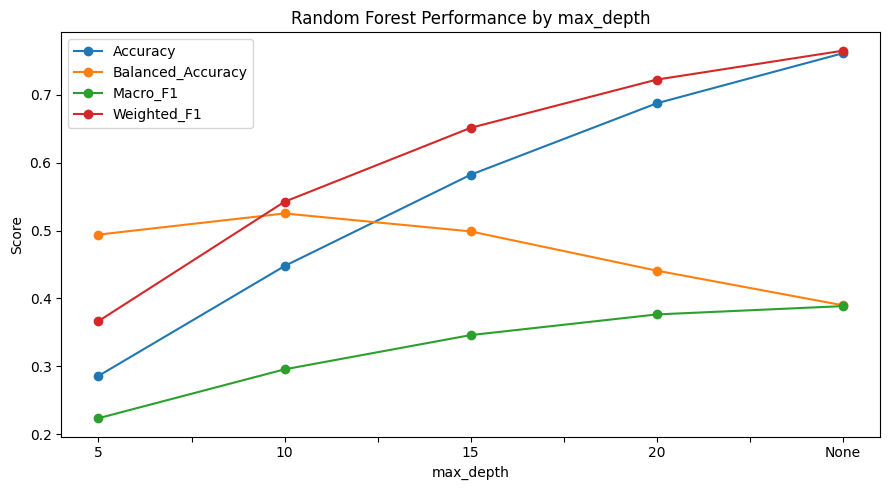

In [36]:
rf_depth_plot_df = rf_depth_df.copy()
rf_depth_plot_df['max_depth'] = ['5', '10', '15', '20', 'None']

rf_depth_plot_df.plot(
    x='max_depth',
    y=['Accuracy', 'Balanced_Accuracy', 'Macro_F1', 'Weighted_F1'],
    marker='o',
    figsize=(9, 5)
)

plt.title('Random Forest Performance by max_depth')
plt.xlabel('max_depth')
plt.ylabel('Score')
plt.tight_layout()
plt.show()

# 33-1. SMOTE 오버샘플링 비교 (한계 보강: 클래스 불균형)

클래스 불균형 한계를 직접 다루기 위해, train 데이터에만 SMOTE 오버샘플링을 적용한 모델을 추가로 비교한다.

핵심 주의사항은 **SMOTE를 train fold에만 적용**해야 한다는 것이다. valid/test까지 오버샘플링하면 정보 누수가 발생한다.  
이를 보장하기 위해 sklearn `Pipeline`이 아니라 `imblearn`의 `Pipeline`을 사용한다 (오버샘플링 단계는 학습 시에만 동작하고 예측 시에는 동작하지 않는다).

SMOTE는 수치형으로 변환된 입력이 필요하므로 dense 전처리(Ordinal Encoding)를 사용한다.

> 참고: 결과적으로 Macro F1 개선이 제한적일 수 있다. 그러나 "오버샘플링을 시도했으나 소수 클래스(Severity 1, 4) 예측 개선이 제한적이었다"는 결과 자체가 클래스 불균형 한계를 보여주는 좋은 분석 근거가 된다.

In [37]:
# imbalanced-learn 설치 확인 (위 환경 설정 셀에서 이미 처리되지만, 단독 실행 대비)
import sys, subprocess
try:
    import imblearn
    print('imbalanced-learn version:', imblearn.__version__)
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'imbalanced-learn'], check=True)
    import imblearn
    print('imbalanced-learn version:', imblearn.__version__)
    print('import 오류가 계속되면 커널을 재시작하세요.')

imbalanced-learn version: 0.14.1


In [38]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# SMOTE는 dense 입력이 필요하므로 dense_preprocessor(Ordinal) 사용.
# imblearn Pipeline을 쓰면 SMOTE는 fit(학습) 시에만 적용되고,
# predict 시에는 valid/test에 적용되지 않는다 -> 누수 없음.
smote_model = ImbPipeline(steps=[
    ('preprocess', dense_preprocessor),
    ('smote', SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
    ('model', HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.08,
        max_leaf_nodes=31,
        random_state=RANDOM_STATE
    ))
])

print('SMOTE + HistGradientBoosting 학습 중')
smote_model.fit(X_train, y_train)

smote_valid_pred = smote_model.predict(X_valid)
smote_valid_result = evaluate_predictions(
    'HistGB + SMOTE', y_valid, smote_valid_pred
)

fitted_models['HistGB + SMOTE'] = smote_model

# 기존 Validation 결과표에 추가하여 비교
validation_result_df = pd.concat(
    [validation_result_df, pd.DataFrame([smote_valid_result])],
    ignore_index=True
).sort_values(by='Macro_F1', ascending=False).reset_index(drop=True)

display(validation_result_df)

SMOTE + HistGradientBoosting 학습 중


,Model,Accuracy,Balanced_Accuracy,Macro_F1,Weighted_F1,Macro_Precision,Macro_Recall
0,Random Forest,0.762749,0.386328,0.384953,0.765768,0.388781,0.386328
1,HistGB + SMOTE,0.800813,0.325177,0.342803,0.769918,0.406506,0.325177
2,XGBoost Balanced,0.525365,0.543391,0.332812,0.604680,0.353554,0.543391
3,HistGradientBoosting,0.811213,0.304214,0.318014,0.763609,0.546433,0.304214
4,Logistic Regression Balanced,0.413039,0.533000,0.283008,0.504828,0.339162,0.533000
5,Logistic Regression,0.801613,0.276575,0.273395,0.742091,0.338006,0.276575
6,Dummy Baseline,0.796680,0.250000,0.221709,0.706525,0.199170,0.250000


# 33-2. Year 변수 영향 실험 (한계 보강: 시간 변화 / 지역·연도 편향)

`Year`는 `Start_Time`에서 만든 변수다. 연도별 데이터 수집 방식, 교통량, 정책 변화 등이 모델에 새어들 수 있어 일반화에 영향을 줄 수 있다.

이를 확인하기 위해 **`Year`를 제외한 동일 모델**을 학습하여 성능 변화를 비교한다.

- 성능이 거의 변하지 않으면 → 모델이 `Year`에 크게 의존하지 않는다는 근거
- 성능이 크게 떨어지면 → 모델이 연도 편향을 학습하고 있었다는 근거

어느 쪽이든 보고서의 "시간 변화 문제" 한계를 뒷받침하는 분석 자료가 된다.

기준 모델로는 RF와 HistGB를 사용한다 (전처리 파이프라인이 컬럼 목록을 참조하므로, Year 제거용 전처리기를 따로 구성한다).

In [39]:
from sklearn.base import clone

# =====================================================================
# Year ablation: Year 포함 모델 vs Year 제외 모델을 공정하게 비교한다.
# 주의 1: 기존 sparse_preprocessor는 앞에서 다른 모델 학습에 이미 사용되어
#         fit 상태가 남아 있을 수 있다. 두 파이프라인이 서로 영향을 주지 않도록
#         전처리기를 각각 새로 만들고, feature 목록도 이 셀에서 새로 계산한다.
# 주의 2: Year의 dtype이 int64가 아닐 수 있으므로(결측으로 float, 또는 nullable),
#         숫자 전체(include='number')와 범주형(object/category)으로 폭넓게 잡는다.
# =====================================================================

# 이 시점의 X_train 컬럼을 기준으로 feature 목록을 새로 산출한다.
num_feats_full = X_train.select_dtypes(include=['number']).columns.tolist()
cat_feats_full = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

print('Year 컬럼 존재:', 'Year' in X_train.columns)
if 'Year' in X_train.columns:
    print('Year dtype:', X_train['Year'].dtype)

# Year가 어느 목록에도 없으면(예: 결측 처리로 빠졌을 때) ablation을 건너뛴다.
if 'Year' not in num_feats_full and 'Year' not in cat_feats_full:
    print('경고: Year가 feature 목록에 없어 ablation을 건너뜁니다.')
    print('수치형 변수 예시:', num_feats_full[:8])
    year_ablation_df = None
else:
    # Year가 범주형으로 잡혔다면 그쪽에서도 제거되도록 양쪽 모두 처리
    num_feats_noyear = [c for c in num_feats_full if c != 'Year']
    cat_feats_noyear = [c for c in cat_feats_full if c != 'Year']

    print('Year 포함 - 수치형:', len(num_feats_full), '/ 범주형:', len(cat_feats_full))
    print('Year 제외 - 수치형:', len(num_feats_noyear), '/ 범주형:', len(cat_feats_noyear))

    def make_sparse_preprocessor(num_cols, cat_cols):
        """매번 새 전처리기를 만들어 fit 상태 공유를 방지한다."""
        return ColumnTransformer(
            transformers=[
                ('num', Pipeline(steps=[
                    ('imputer', SimpleImputer(strategy='median')),
                    ('scaler', StandardScaler())
                ]), num_cols),
                ('cat', Pipeline(steps=[
                    ('imputer', SimpleImputer(strategy='most_frequent')),
                    ('onehot', OneHotEncoder(handle_unknown='ignore'))
                ]), cat_cols)
            ],
            sparse_threshold=1.0
        )

    # 원본 X_train을 변형하지 않도록 복사
    X_train_with_year = X_train.copy()
    X_valid_with_year = X_valid.copy()
    X_train_noyear = X_train.drop(columns=['Year'])
    X_valid_noyear = X_valid.drop(columns=['Year'])

    rf_params = dict(
        n_estimators=200, max_depth=None, min_samples_leaf=3,
        class_weight='balanced_subsample',
        random_state=RANDOM_STATE, n_jobs=-1
    )

    rf_with_year = Pipeline(steps=[
        ('preprocess', make_sparse_preprocessor(num_feats_full, cat_feats_full)),
        ('model', RandomForestClassifier(**rf_params))
    ])
    rf_without_year = Pipeline(steps=[
        ('preprocess', make_sparse_preprocessor(num_feats_noyear, cat_feats_noyear)),
        ('model', RandomForestClassifier(**rf_params))
    ])

    print('RF (Year 포함) 학습 중')
    rf_with_year.fit(X_train_with_year, y_train)
    print('RF (Year 제외) 학습 중')
    rf_without_year.fit(X_train_noyear, y_train)

    # 변환 후 feature 수가 실제로 다른지 확인 (1 차이여야 정상)
    n_with = rf_with_year.named_steps['preprocess'].transform(X_valid_with_year).shape[1]
    n_without = rf_without_year.named_steps['preprocess'].transform(X_valid_noyear).shape[1]
    print(f'변환 후 feature 수 - Year 포함: {n_with}, Year 제외: {n_without} (차이: {n_with - n_without})')

    year_ablation_results = [
        evaluate_predictions('RF with Year',    y_valid, rf_with_year.predict(X_valid_with_year)),
        evaluate_predictions('RF without Year', y_valid, rf_without_year.predict(X_valid_noyear)),
    ]

    year_ablation_df = pd.DataFrame(year_ablation_results)
    display(year_ablation_df)

    diff = (year_ablation_df.set_index('Model').loc['RF with Year']
            - year_ablation_df.set_index('Model').loc['RF without Year'])
    print('Year 포함 - 제외 (양수면 Year가 성능에 기여):')
    display(diff[metric_cols])


Year 컬럼 존재: True
Year dtype: int32
Year 포함 - 수치형: 27 / 범주형: 10
Year 제외 - 수치형: 26 / 범주형: 10
RF (Year 포함) 학습 중
RF (Year 제외) 학습 중
변환 후 feature 수 - Year 포함: 181, Year 제외: 180 (차이: 1)


,Model,Accuracy,Balanced_Accuracy,Macro_F1,Weighted_F1,Macro_Precision,Macro_Recall
0,RF with Year,0.788214,0.426470,0.444059,0.786109,0.512217,0.426470
1,RF without Year,0.781481,0.374186,0.384640,0.774021,0.416779,0.374186


Year 포함 - 제외 (양수면 Year가 성능에 기여):


Accuracy             0.006733
Balanced_Accuracy    0.052284
Macro_F1             0.059419
Weighted_F1          0.012088
Macro_Precision      0.095438
Macro_Recall         0.052284
dtype: float64

# 34. 결과 저장

모델 비교 결과와 최종 평가 결과를 CSV 파일로 저장한다.

In [40]:
validation_result_df.to_csv('validation_model_results.csv', index=False)
test_result_df.to_csv('test_result_best_model.csv', index=False)
rf_depth_df.to_csv('rf_depth_results.csv', index=False)
if year_ablation_df is not None:
    year_ablation_df.to_csv('year_ablation_results.csv', index=False)

print('결과 CSV 저장 완료')

결과 CSV 저장 완료


# 35. 보고서용 요약 출력

보고서 작성에 필요한 핵심 정보를 한 번에 확인한다.

In [41]:
print('========== 보고서용 요약 ==========')
print('원본 데이터 크기:', df.shape)
print('샘플링 후 데이터 크기:', sampled_df.shape)
print('전처리 후 데이터 크기:', data.shape)
print('입력 변수 수:', X.shape[1])
print('Train / Validation / Test:', X_train.shape[0], X_valid.shape[0], X_test.shape[0])
print('최종 선택 모델:', best_model_name)

print('Validation 결과')
display(validation_result_df)

print('Test 결과')
display(test_result_df)

print('해석 메모')
print('- Accuracy가 높더라도 클래스 불균형 때문에 성능이 과대평가될 수 있다.')
print('- Dummy Baseline과 비교하여 실제 모델의 개선 정도를 확인한다.')
print('- Balanced Accuracy, Macro F1, Confusion Matrix를 함께 해석한다.')
print('- 위치 변수는 예측에 도움이 될 수 있지만 지역적 편향을 반영할 가능성이 있다.')
print('- End_Time, Duration_Min, Distance(mi)는 정보 누수 가능성이 있어 제외하였다.')

========== 보고서용 요약 ==========
원본 데이터 크기: (7728394, 34)
샘플링 후 데이터 크기: (100000, 34)
전처리 후 데이터 크기: (100000, 38)
입력 변수 수: 37
Train / Validation / Test: 69999 15001 15000
최종 선택 모델: Random Forest
Validation 결과


,Model,Accuracy,Balanced_Accuracy,Macro_F1,Weighted_F1,Macro_Precision,Macro_Recall
0,Random Forest,0.762749,0.386328,0.384953,0.765768,0.388781,0.386328
1,HistGB + SMOTE,0.800813,0.325177,0.342803,0.769918,0.406506,0.325177
2,XGBoost Balanced,0.525365,0.543391,0.332812,0.604680,0.353554,0.543391
3,HistGradientBoosting,0.811213,0.304214,0.318014,0.763609,0.546433,0.304214
4,Logistic Regression Balanced,0.413039,0.533000,0.283008,0.504828,0.339162,0.533000
5,Logistic Regression,0.801613,0.276575,0.273395,0.742091,0.338006,0.276575
6,Dummy Baseline,0.796680,0.250000,0.221709,0.706525,0.199170,0.250000


Test 결과


,Model,Accuracy,Balanced_Accuracy,Macro_F1,Weighted_F1,Macro_Precision,Macro_Recall
0,Random Forest,0.7576,0.406675,0.40525,0.763043,0.409807,0.406675


해석 메모
- Accuracy가 높더라도 클래스 불균형 때문에 성능이 과대평가될 수 있다.
- Dummy Baseline과 비교하여 실제 모델의 개선 정도를 확인한다.
- Balanced Accuracy, Macro F1, Confusion Matrix를 함께 해석한다.
- 위치 변수는 예측에 도움이 될 수 있지만 지역적 편향을 반영할 가능성이 있다.
- End_Time, Duration_Min, Distance(mi)는 정보 누수 가능성이 있어 제외하였다.


# 36. 보고서 작성 시 해석 방향

## Approach에 쓸 내용

- 사고 발생 시점에서 활용 가능한 시간, 위치, 기상, 도로환경 변수를 사용하였다.
- 정보 누수 가능성이 있는 `End_Time`, `Duration_Min`, `Distance(mi)`는 제외하였다.
- `Weather_Condition`은 세부 범주가 많아 `Weather_Group`으로 단순화하였다.
- 클래스 분포 유지를 위해 `Severity` 기준 층화 샘플링을 적용하였다.

## Results에 쓸 내용

- 모델별 Validation 성능표를 제시한다.
- 최종 모델은 Validation Macro F1 기준으로 선택하였다.
- 최종 모델의 Test 성능을 별도로 제시한다.

## Analysis에 쓸 내용

- Accuracy가 높더라도 Dummy Baseline과 비교해야 한다.
- 클래스 불균형 때문에 Macro F1과 Balanced Accuracy가 중요하다.
- Confusion Matrix를 통해 소수 클래스 예측 한계를 분석한다.
- Feature Importance를 통해 위치, 시간, 기상, 도로환경 변수의 상대적 영향력을 설명한다.
- 위치 변수는 특정 지역의 데이터 편향을 반영할 수 있으므로 일반화에 한계가 있다.

## 한계점 및 보강 분석 (Limitations)

본 분석에서 확인된 한계와, 코드로 직접 보강한 부분을 함께 정리한다.

### 코드로 보강한 항목

- **클래스 불균형**: Severity 2가 대부분을 차지하여 Accuracy가 과대평가되기 쉽다. `class_weight='balanced'`(RF, LR), XGBoost의 `sample_weight`, 그리고 SMOTE 오버샘플링(train 한정)을 적용해 비교하였다. 다만 소수 클래스(Severity 1, 4)의 Macro F1·Recall 개선은 제한적이었으며, 이는 표본 자체가 부족한 데서 오는 근본적 한계다.
- **전처리 정보 누수 제거**: City/County 상위 30개 범주 목록을 train 데이터에서만 학습하여 valid/test에 적용하도록 수정하였다. 이전에는 전체 샘플 기준으로 계산되어 미세한 누수가 있었다.
- **모델 비교 공정성**: 기존에는 XGBoost만 불균형 보정이 없었으나, `sample_weight`를 적용하여 다른 모델과 동일한 조건으로 비교하였다.
- **시간 변화 / 연도 편향**: `Year` 변수를 포함한 모델과 제외한 모델을 비교(ablation)하여, 모델이 연도별 수집 편향에 의존하는 정도를 정량적으로 확인하였다.

### 데이터 특성상 서술로 남기는 항목

- **Severity 정의의 한계**: Severity는 실제 부상 정도나 사망 여부가 아니라 사고의 교통 영향 수준에 가깝다. 따라서 본 모델은 의학적 심각도가 아니라 영향 수준을 예측하는 것으로 해석해야 한다.
- **정보 누수 방지를 위한 변수 제외의 트레이드오프**: `Distance(mi)`, `End_Time`, `Duration_Min` 등을 포함하면 성능은 높아지지만, 이는 사고 발생 시점에는 알 수 없는 정보다. 성능을 일부 포기하더라도 실사용 가능한(예측 시점에 활용 가능한) 모델을 구성하는 것이 더 타당하다.
- **지역 편향**: 미국 전체 데이터지만 특정 주·도시의 사고 기록이 과도하게 많아, 위치 변수가 지역적 편향을 학습할 수 있다. 다른 지역·기간으로의 일반화에는 한계가 있다.
- **변수 중복성**: `Wind_Chill(F)`는 Temperature와 Wind_Speed에서 파생되는 값으로 정보가 중복되며 결측도 많아 실질 기여가 제한적일 수 있다.
- **Feature Importance 해석**: Feature Importance는 예측 기여도를 나타낼 뿐 인과관계를 의미하지 않는다.